In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
train_path = "dataset/casting_data/train"
test_path = "dataset/casting_data/test"

In [3]:
IMG_SIZE = (128,128)

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=32
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=32
)

Found 6633 files belonging to 2 classes.
Found 715 files belonging to 2 classes.


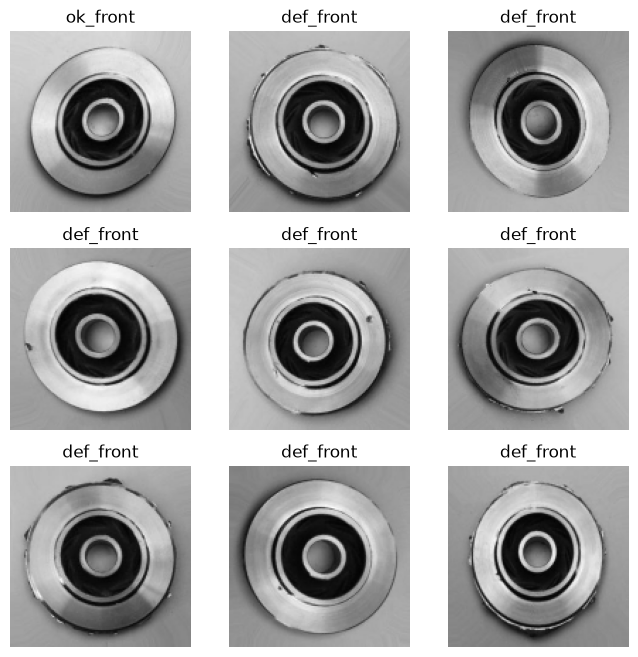

In [4]:
class_names = train_dataset.class_names

plt.figure(figsize=(8,8))

for images, labels in train_dataset.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [5]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))

test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))

In [6]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.1),

    tf.keras.layers.RandomZoom(0.1),

])

In [7]:
model = tf.keras.Sequential([

    data_augmentation,

    tf.keras.layers.Conv2D(32,3,activation='relu'),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,3,activation='relu'),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,3,activation='relu'),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation='relu'),

    tf.keras.layers.Dense(2,activation='softmax')

])

In [9]:
history = model.fit(

    train_dataset,

    epochs=10,

    validation_data=test_dataset

)

Epoch 1/10


D:\Anaconda\envs\opencv-env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


208/208 ━━━━━━━━━━━━━━━━━━━━ 92s 405ms/step - accuracy: 0.6077 - loss: 0.6578 - val_accuracy: 0.7329 - val_loss: 0.5174
Epoch 2/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 87s 418ms/step - accuracy: 0.8274 - loss: 0.3769 - val_accuracy: 0.6853 - val_loss: 0.6919
Epoch 3/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 79s 377ms/step - accuracy: 0.9037 - loss: 0.2326 - val_accuracy: 0.9091 - val_loss: 0.2310
Epoch 4/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 76s 365ms/step - accuracy: 0.9343 - loss: 0.1678 - val_accuracy: 0.8615 - val_loss: 0.3492
Epoch 5/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 84s 404ms/step - accuracy: 0.9552 - loss: 0.1222 - val_accuracy: 0.7538 - val_loss: 0.7017
Epoch 6/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 364s 1s/step - accuracy: 0.9659 - loss: 0.1010 - val_accuracy: 0.8727 - val_loss: 0.3635
Epoch 7/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.9727 - loss: 0.0789 - val_accuracy: 0.8434 - val_loss: 0.4960
Epoch 8/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 91s 437ms/step - accuracy: 0.9708 - loss: 0.0829 - val_acc

In [10]:
loss, accuracy = model.evaluate(test_dataset)

print("Test Accuracy:", accuracy)

23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 438ms/step - accuracy: 0.9580 - loss: 0.1012
Test Accuracy: 0.9580419659614563


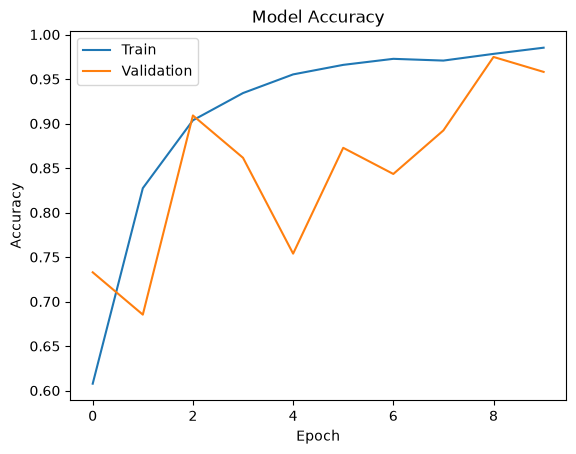

In [11]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

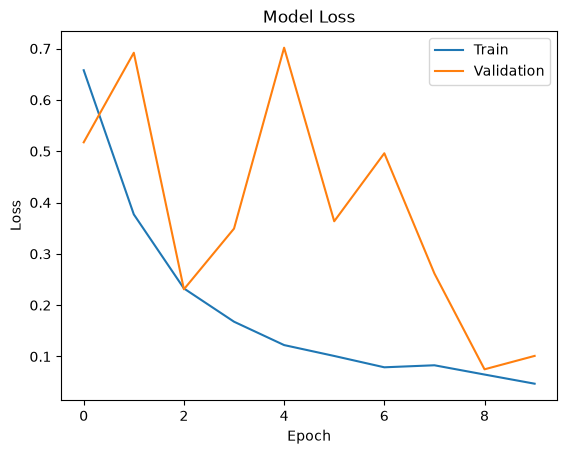

In [12]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

In [14]:
model.save("models/defect_detection_model.keras")

In [16]:
image = tf.keras.utils.load_img(
    "dataset/casting_data/test/ok_front/cast_ok_0_10.jpeg",
    target_size=(128,128)
)

img_array = tf.keras.utils.img_to_array(image)

img_array = img_array/255

img_array = tf.expand_dims(img_array,0)

prediction = model.predict(img_array)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
[[0.00282292 0.9971771 ]]
